# =====================================================
# NOTEBOOK INFORMATION
# =====================================================

# Privacy-Preserving Federated Network Intrusion Detection System

## Notebook 05 - Baseline Model Comparison

### Objectives

- Load the feature-engineered training and testing datasets
- Scale features without data leakage
- Train baseline machine learning models
- Compare model performance
- Generate evaluation metrics and visualizations
- Identify the strongest centralized baseline

In [2]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULTS_PATH = PROJECT_ROOT / "results"
METRICS_PATH = RESULTS_PATH / "metrics"
FIGURES_PATH = RESULTS_PATH / "figures"
MODELS_PATH = RESULTS_PATH / "models"

for path in [
    METRICS_PATH,
    FIGURES_PATH,
    MODELS_PATH
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )

TRAIN_PATH = (
    PROCESSED_DATA_PATH
    / "CICIDS2017_train.csv"
)

TEST_PATH = (
    PROCESSED_DATA_PATH
    / "CICIDS2017_test.csv"
)

print("Training file:", TRAIN_PATH)
print("Testing file :", TEST_PATH)

Training file: c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_train.csv
Testing file : c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_test.csv


In [4]:
# =====================================================
# LOAD TRAINING AND TESTING DATA
# =====================================================

train_df = pd.read_csv(
    TRAIN_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    f"Training shape: {train_df.shape}"
)

print(
    f"Testing shape : {test_df.shape}"
)

Training shape: (2016638, 49)
Testing shape : (504160, 49)


In [5]:
# =====================================================
# SEPARATE FEATURES, ROW IDs AND TARGET
# =====================================================

# Keep the original row IDs separately.
# They are NOT ML features.

train_row_ids = train_df["Original_Row_ID"].values
test_row_ids = test_df["Original_Row_ID"].values


X_train = train_df.drop(
    columns=["Label", "Original_Row_ID"]
)

y_train = train_df["Label"]


X_test = test_df.drop(
    columns=["Label", "Original_Row_ID"]
)

y_test = test_df["Label"]


print(
    f"Training features: {X_train.shape}"
)

print(
    f"Testing features : {X_test.shape}"
)

print(
    f"Number of classes: {y_train.nunique()}"
)

print(
    f"\nTraining row IDs: {len(train_row_ids):,}"
)

print(
    f"Testing row IDs : {len(test_row_ids):,}"
)

Training features: (2016638, 47)
Testing features : (504160, 47)
Number of classes: 15

Training row IDs: 2,016,638
Testing row IDs : 504,160


In [6]:
# =====================================================
# ENCODE TARGET LABELS
# =====================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

print("Classes:")

for number, label in enumerate(
    label_encoder.classes_
):
    print(
        f"{number}: {label}"
    )

Classes:
0: BENIGN
1: Bot
2: DDoS
3: DoS GoldenEye
4: DoS Hulk
5: DoS Slowhttptest
6: DoS slowloris
7: FTP-Patator
8: Heartbleed
9: Infiltration
10: PortScan
11: SSH-Patator
12: Web Attack � Brute Force
13: Web Attack � Sql Injection
14: Web Attack � XSS


In [7]:
# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

print(
    "Training shape:",
    X_train_scaled.shape
)

print(
    "Testing shape :",
    X_test_scaled.shape
)

Feature scaling completed.
Training shape: (2016638, 47)
Testing shape : (504160, 47)


In [8]:
# =====================================================
# DEFINE BASELINE MODELS
# =====================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

print("Models defined successfully.")

for model_name in models:
    print("-", model_name)

Models defined successfully.
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


In [55]:
# =====================================================
# TRAIN BASELINE MODELS
# =====================================================

results = []
trained_models = {}
predictions_dict = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    # Train model
    model.fit(
        X_train_scaled,
        y_train_encoded
    )

    # Predict test data
    predictions = model.predict(
        X_test_scaled
    )

    # -------------------------------------------------
    # BASIC METRICS
    # -------------------------------------------------

    accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    # Weighted metrics
    weighted_precision = precision_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    # -------------------------------------------------
    # MACRO METRICS
    # -------------------------------------------------

    macro_precision = precision_score(
        y_test_encoded,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test_encoded,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test_encoded,
        predictions,
        average="macro",
        zero_division=0
    )

    # -------------------------------------------------
    # SAVE RESULTS
    # -------------------------------------------------

    results.append({
        "Model": name,
        "Accuracy": accuracy,

        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1": weighted_f1,

        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })

    trained_models[name] = model
    predictions_dict[name] = predictions

    # -------------------------------------------------
    # PRINT RESULTS
    # -------------------------------------------------

    print(f"Accuracy          : {accuracy:.4f}")

    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall   : {weighted_recall:.4f}")
    print(f"Weighted F1       : {weighted_f1:.4f}")

    print(f"Macro Precision   : {macro_precision:.4f}")
    print(f"Macro Recall      : {macro_recall:.4f}")
    print(f"Macro F1          : {macro_f1:.4f}")


Training: Logistic Regression
Accuracy          : 0.8335
Weighted Precision: 0.9648
Weighted Recall   : 0.8335
Weighted F1       : 0.8864
Macro Precision   : 0.3946
Macro Recall      : 0.9192
Macro F1          : 0.4717

Training: Decision Tree
Accuracy          : 0.9983
Weighted Precision: 0.9983
Weighted Recall   : 0.9983
Weighted F1       : 0.9983
Macro Precision   : 0.9069
Macro Recall      : 0.8823
Macro F1          : 0.8883

Training: Random Forest
Accuracy          : 0.9981
Weighted Precision: 0.9985
Weighted Recall   : 0.9981
Weighted F1       : 0.9983
Macro Precision   : 0.8795
Macro Recall      : 0.8643
Macro F1          : 0.8583

Training: XGBoost
Accuracy          : 0.9989
Weighted Precision: 0.9988
Weighted Recall   : 0.9989
Weighted F1       : 0.9988
Macro Precision   : 0.9550
Macro Recall      : 0.8473
Macro F1          : 0.8780


In [18]:
# =====================================================
# MODEL COMPARISON
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
)

results_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,Decision Tree,0.998298,0.998289,0.998298,0.998292,0.906887,0.882294,0.888313
3,XGBoost,0.998854,0.998843,0.998854,0.998790,0.955018,0.847279,0.877991
2,Random Forest,0.998139,0.998510,0.998139,0.998262,0.879527,0.864335,0.858332
0,Logistic Regression,0.833521,0.964807,0.833521,0.886408,0.394579,0.919243,0.471685


In [27]:
# =====================================================
# FORMAT PERFORMANCE RESULTS
# =====================================================

display_df = results_df.copy()

percentage_columns = [
    "Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

for column in percentage_columns:
    display_df[column] = (
        display_df[column] * 100
    ).round(2)

display_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,Decision Tree,99.83,99.83,99.83,99.83,90.69,88.23,88.83
3,XGBoost,99.89,99.88,99.89,99.88,95.50,84.73,87.80
2,Random Forest,99.81,99.85,99.81,99.83,87.95,86.43,85.83
0,Logistic Regression,83.35,96.48,83.35,88.64,39.46,91.92,47.17


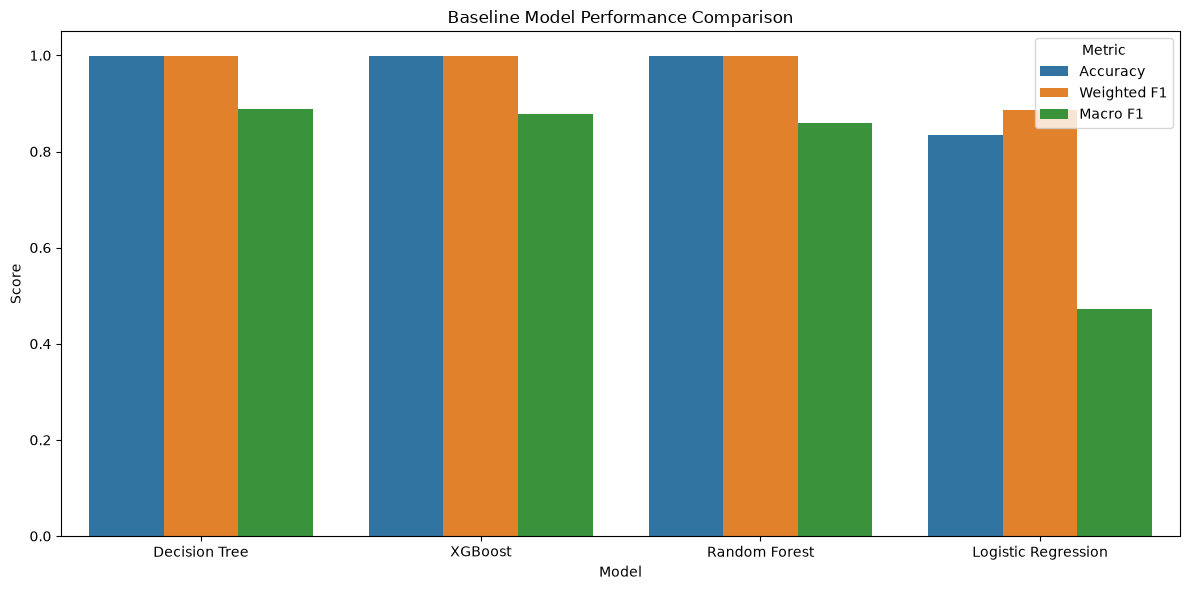

In [28]:
# =====================================================
# MODEL PERFORMANCE VISUALIZATION
# =====================================================

plot_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Weighted F1",
        "Macro F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)

plt.title(
    "Baseline Model Performance Comparison"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.tight_layout()

plt.show()

In [30]:
# =====================================================
# SELECT BEST CENTRALIZED MODEL
# =====================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_row = results_df.iloc[0]

print(
    f"Best centralized model by Macro F1: "
    f"{best_model_name}"
)

print(
    f"Accuracy  : "
    f"{best_row['Accuracy']:.4f}"
)

print(
    f"Weighted F1: "
    f"{best_row['Weighted F1']:.4f}"
)

print(
    f"Macro F1   : "
    f"{best_row['Macro F1']:.4f}"
)

Best centralized model by Macro F1: Decision Tree
Accuracy  : 0.9983
Weighted F1: 0.9983
Macro F1   : 0.8883


In [31]:
# =====================================================
# CLASSIFICATION REPORT
# =====================================================

best_predictions = predictions_dict[
    best_model_name
]

print(
    f"Classification Report - "
    f"{best_model_name}"
)

print()

print(
    classification_report(
        y_test_encoded,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Classification Report - Decision Tree

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.85      0.84      0.85       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.98      0.99      0.98      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack � Brute Force       0.74      0.78      0.76       294
Web Atta

In [32]:
# =====================================================
# PER-CLASS PERFORMANCE SUMMARY
# =====================================================

report = classification_report(
    y_test_encoded,
    best_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

class_report_df = report_df.iloc[:-3].copy()

class_report_df = class_report_df.sort_values(
    by="recall",
    ascending=True
)

print("Classes with lowest recall:")
display(
    class_report_df[
        ["precision", "recall", "f1-score", "support"]
    ]
)

Classes with lowest recall:


,precision,recall,f1-score,support
Web Attack � XSS,0.464912,0.407692,0.434426,130.0
Heartbleed,1.000000,0.500000,0.666667,2.0
Web Attack � Sql Injection,0.600000,0.750000,0.666667,4.0
Web Attack � Brute Force,0.741935,0.782313,0.761589,294.0
Bot,0.849741,0.841026,0.845361,390.0
DoS slowloris,0.991597,0.986072,0.988827,1077.0
PortScan,0.988419,0.988092,0.988255,18139.0
DoS GoldenEye,0.992701,0.991736,0.992218,2057.0
DoS Slowhttptest,0.977401,0.992352,0.984820,1046.0
DoS Hulk,0.998409,0.998409,0.998409,34569.0


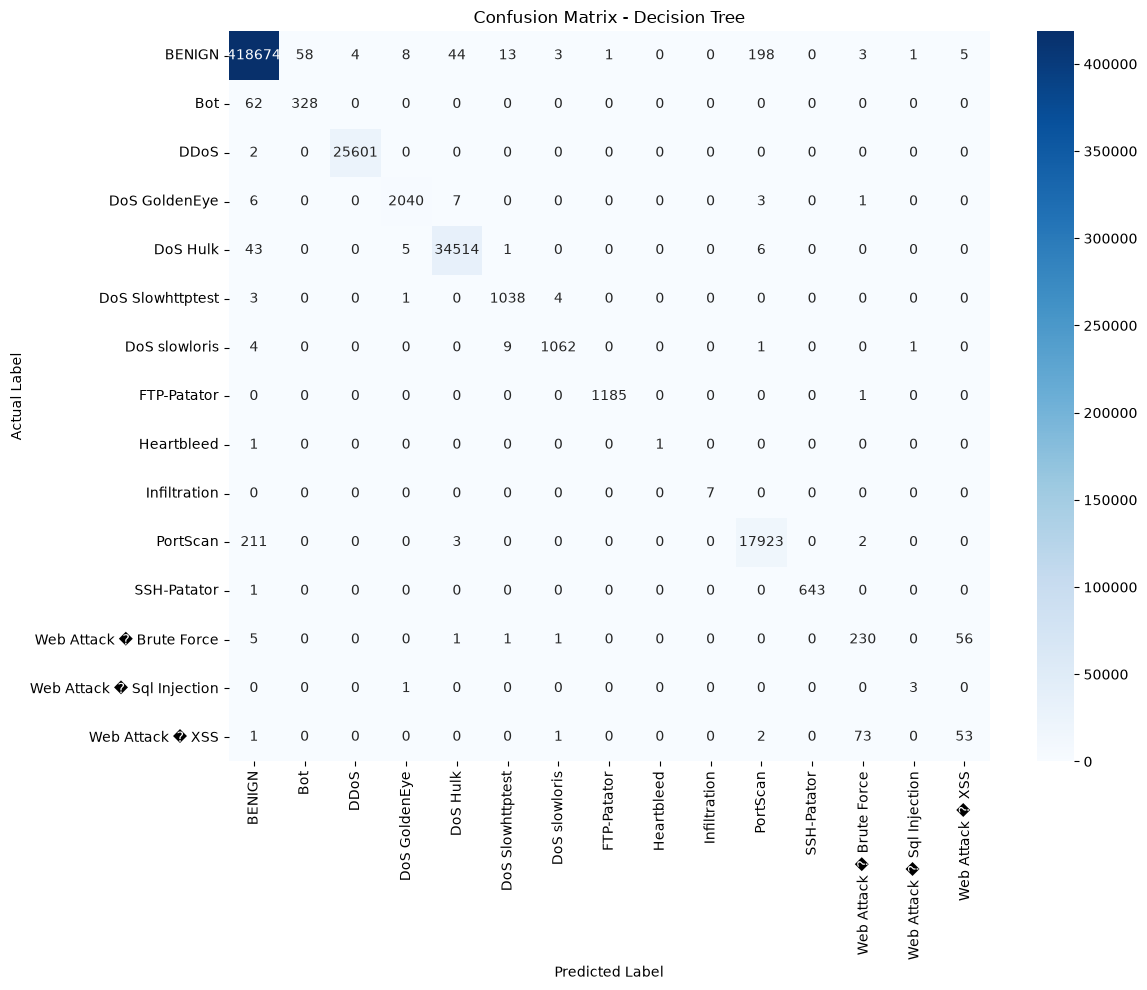

In [33]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test_encoded,
    best_predictions
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH
    / "baseline_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# =====================================================
# SAVE MODEL COMPARISON RESULTS
# =====================================================

results_df.to_csv(
    METRICS_PATH / "baseline_model_comparison.csv",
    index=False
)

print(
    "Baseline results saved successfully."
)

Baseline results saved successfully.


In [35]:
# =====================================================
# SAVE LABEL ENCODER MAPPING
# =====================================================

label_mapping = pd.DataFrame({
    "Encoded_Label": range(
        len(label_encoder.classes_)
    ),
    "Original_Label":
        label_encoder.classes_
})

label_mapping.to_csv(
    METRICS_PATH
    / "baseline_label_mapping.csv",
    index=False
)

label_mapping

,Encoded_Label,Original_Label
0,0,BENIGN
1,1,Bot
2,2,DDoS
3,3,DoS GoldenEye
4,4,DoS Hulk
5,5,DoS Slowhttptest
6,6,DoS slowloris
7,7,FTP-Patator
8,8,Heartbleed
9,9,Infiltration


In [37]:
# =====================================================
# VALIDATION CHECK 1
# TRAIN / TEST EXACT DUPLICATE OVERLAP
# =====================================================

print("=" * 60)
print("TRAIN / TEST DUPLICATE OVERLAP CHECK")
print("=" * 60)

train_hashes = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_hashes = pd.util.hash_pandas_object(
    X_test,
    index=False
)

train_hash_set = set(train_hashes)
test_hash_set = set(test_hashes)

overlap = len(
    train_hash_set.intersection(test_hash_set)
)

print(
    f"Training rows : {len(X_train):,}"
)

print(
    f"Testing rows  : {len(X_test):,}"
)

print(
    f"Exact duplicate rows shared: {overlap:,}"
)

if overlap == 0:

    print("\nPASS")
    print(
        "No exact duplicate feature rows "
        "are shared between train and test."
    )

else:

    print("\nWARNING")
    print(
        "Identical feature rows exist in "
        "both train and test."
    )

TRAIN / TEST DUPLICATE OVERLAP CHECK
Training rows : 2,016,638
Testing rows  : 504,160
Exact duplicate rows shared: 217

WARNING
Identical feature rows exist in both train and test.


In [38]:
# =====================================================
# VALIDATION CHECK 2
# INVESTIGATE TRAIN / TEST OVERLAPPING ROWS
# =====================================================

print("=" * 60)
print("INVESTIGATING OVERLAPPING TRAIN / TEST ROWS")
print("=" * 60)

# Find hashes appearing in both sets
train_hashes_series = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_hashes_series = pd.util.hash_pandas_object(
    X_test,
    index=False
)

train_hash_set = set(train_hashes_series)
test_hash_set = set(test_hashes_series)

overlap_hashes = (
    train_hash_set.intersection(test_hash_set)
)

print(
    f"Overlapping unique feature rows: "
    f"{len(overlap_hashes):,}"
)

# -----------------------------------------------------
# Check labels associated with overlapping rows
# -----------------------------------------------------

train_hash_to_labels = {}

for row_hash, label in zip(
    train_hashes_series,
    y_train
):
    train_hash_to_labels.setdefault(
        row_hash,
        set()
    ).add(label)

test_hash_to_labels = {}

for row_hash, label in zip(
    test_hashes_series,
    y_test
):
    test_hash_to_labels.setdefault(
        row_hash,
        set()
    ).add(label)

same_label = 0
different_label = 0

conflicting_examples = []

for row_hash in overlap_hashes:

    train_labels = train_hash_to_labels[row_hash]
    test_labels = test_hash_to_labels[row_hash]

    if train_labels == test_labels:

        same_label += 1

    else:

        different_label += 1

        conflicting_examples.append({
            "Hash": row_hash,
            "Train Labels": train_labels,
            "Test Labels": test_labels
        })

print(
    f"\nSame-label overlaps      : {same_label:,}"
)

print(
    f"Different-label overlaps : {different_label:,}"
)

if different_label == 0:

    print(
        "\nPASS: All overlapping rows "
        "have consistent labels."
    )

else:

    print(
        "\nWARNING: Some overlapping rows "
        "have conflicting labels."
    )

    display(
        pd.DataFrame(
            conflicting_examples
        ).head(20)
    )

INVESTIGATING OVERLAPPING TRAIN / TEST ROWS
Overlapping unique feature rows: 217

Same-label overlaps      : 0
Different-label overlaps : 217



,Hash,Train Labels,Test Labels
0,11633707494606630907,{PortScan},{BENIGN}
1,7300995572963382271,{PortScan},{BENIGN}
2,8300975937607145984,{DoS Hulk},{BENIGN}
3,189085739602106885,{PortScan},{BENIGN}
4,14359989453506813952,{PortScan},{BENIGN}
5,10878589822820661761,{BENIGN},{PortScan}
6,16302195269861705216,{PortScan},{BENIGN}
7,15663270024326572547,{DoS Hulk},{BENIGN}
8,9949728207726825475,{BENIGN},{DoS Hulk}
9,12567808208176649222,{BENIGN},{PortScan}


In [40]:
# =====================================================
# VALIDATION CHECK 3
# INVESTIGATE CONFLICTS BEFORE FEATURE REDUCTION
# =====================================================

print("=" * 60)
print("CHECKING CONFLICTS IN ORIGINAL FEATURES")
print("=" * 60)

# Load the clean dataset used before feature selection
original_df = pd.read_csv(r"C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\processed\CICIDS2017_clean.csv")

# Separate original features and labels
X_original = original_df.drop(columns=["Label"])
y_original = original_df["Label"]

print("Original feature count:", X_original.shape[1])
print("Original rows:", len(X_original))

# -----------------------------------------------------
# Find exact duplicate feature rows in the ORIGINAL
# 78-feature dataset
# -----------------------------------------------------

original_hashes = pd.util.hash_pandas_object(
    X_original,
    index=False
)

hash_to_labels = {}

for row_hash, label in zip(
    original_hashes,
    y_original
):
    hash_to_labels.setdefault(
        row_hash,
        set()
    ).add(label)

conflicting_original_rows = []

for row_hash, labels in hash_to_labels.items():

    if len(labels) > 1:

        conflicting_original_rows.append({
            "Hash": row_hash,
            "Labels": labels
        })

print(
    "\nOriginal feature rows with "
    "multiple labels:",
    len(conflicting_original_rows)
)

if len(conflicting_original_rows) == 0:

    print(
        "\nPASS:"
        "\nNo conflicting labels exist "
        "in the original 78-feature data."
    )

else:

    print(
        "\nWARNING:"
        "\nConflicting labels already exist "
        "in the original data."
    )

    display(
        pd.DataFrame(
            conflicting_original_rows
        ).head(20)
    )

CHECKING CONFLICTS IN ORIGINAL FEATURES
Original feature count: 78
Original rows: 2520798

Original feature rows with multiple labels: 697

Conflicting labels already exist in the original data.


,Hash,Labels
0,14780546301552177491,"{DoS Hulk, BENIGN}"
1,11921086800570957975,"{DDoS, BENIGN}"
2,10318351393522193286,"{DoS Hulk, BENIGN}"
3,10143674442682735830,"{DDoS, BENIGN}"
4,5637169386660079786,"{DDoS, BENIGN}"
5,16375128299168764083,"{DoS Hulk, BENIGN}"
6,17957479058742657271,"{DoS Hulk, BENIGN}"
7,742474177450153542,"{DoS Hulk, BENIGN}"
8,1676153123259510862,"{DoS Hulk, BENIGN}"
9,16699817225246313848,"{DoS Hulk, BENIGN}"


In [41]:
# =====================================================
# VALIDATION CHECK 4
# INSPECT CONFLICTING ORIGINAL RECORDS
# =====================================================

print("=" * 60)
print("INSPECTING CONFLICTING ORIGINAL RECORDS")
print("=" * 60)

# Add labels back temporarily
original_with_label = original_df.copy()

# Find feature columns
feature_columns = [
    col for col in original_with_label.columns
    if col != "Label"
]

# Find duplicated feature patterns
duplicated_features = (
    original_with_label
    .duplicated(
        subset=feature_columns,
        keep=False
    )
)

conflict_df = original_with_label[
    duplicated_features
].copy()

# Keep only feature patterns associated
# with more than one label
label_counts = (
    conflict_df
    .groupby(feature_columns)["Label"]
    .nunique()
)

conflicting_patterns = label_counts[
    label_counts > 1
].reset_index()

print(
    "Conflicting feature patterns:",
    len(conflicting_patterns)
)

print("\nExample conflicting records:")

display(
    conflict_df.head(20)
)

INSPECTING CONFLICTING ORIGINAL RECORDS
Conflicting feature patterns: 697

Example conflicting records:


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
14886,80,87,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
18996,80,4,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
40429,80,153,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
81615,80,6,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
159513,80,3,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
215774,80,121,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
215813,80,176,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
231798,80,156,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
233090,80,1,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
233382,80,144,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [42]:
# =====================================================
# VALIDATION CHECK 4A
# SHOW ACTUAL CONFLICTING RECORDS
# =====================================================

print("=" * 60)
print("SHOWING ACTUAL CONFLICTING RECORDS")
print("=" * 60)

# Find feature columns
feature_columns = [
    col for col in original_df.columns
    if col != "Label"
]

# Find duplicated feature patterns
duplicated_features = original_df.duplicated(
    subset=feature_columns,
    keep=False
)

duplicate_df = original_df[
    duplicated_features
].copy()

# Find feature patterns having MORE THAN ONE label
label_counts = (
    duplicate_df
    .groupby(feature_columns)["Label"]
    .nunique()
)

conflicting_patterns = label_counts[
    label_counts > 1
]

print(
    f"Conflicting feature patterns: "
    f"{len(conflicting_patterns):,}"
)

# -----------------------------------------------------
# Select only rows belonging to conflicting patterns
# -----------------------------------------------------

conflict_index = (
    duplicate_df
    .set_index(feature_columns)
    .index.isin(conflicting_patterns.index)
)

actual_conflicts = duplicate_df[
    conflict_index
].copy()

print(
    f"Rows involved in conflicts: "
    f"{len(actual_conflicts):,}"
)

# -----------------------------------------------------
# Show only useful identifying columns + label
# -----------------------------------------------------

preferred_columns = [
    "Flow ID",
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Protocol",
    "Timestamp",
    "Label"
]

show_columns = [
    col for col in preferred_columns
    if col in actual_conflicts.columns
]

print("\nConflicting records:")
display(
    actual_conflicts[
        show_columns
    ].head(50)
)

SHOWING ACTUAL CONFLICTING RECORDS
Conflicting feature patterns: 697
Rows involved in conflicts: 1,394

Conflicting records:


,Label
14886,BENIGN
18996,DDoS
40429,BENIGN
81615,DDoS
159513,DDoS
215774,BENIGN
215813,BENIGN
231798,BENIGN
233090,BENIGN
233382,BENIGN


In [43]:
# =====================================================
# VALIDATION CHECK 4B
# INSPECT ONE CONFLICTING FEATURE PATTERN
# =====================================================

print("=" * 60)
print("INSPECTING ONE CONFLICTING FEATURE PATTERN")
print("=" * 60)

# Get the first conflicting feature pattern
first_conflict = conflicting_patterns.index[0]

# Retrieve all rows having that exact feature pattern
one_conflict = original_df[
    original_df[feature_columns]
    .apply(tuple, axis=1)
    .isin([tuple(first_conflict)])
].copy()

print("Number of records in this pattern:")
print(len(one_conflict))

print("\nLabels:")
print(one_conflict["Label"].value_counts())

print("\nFull feature values:")
display(one_conflict.T)

INSPECTING ONE CONFLICTING FEATURE PATTERN
Number of records in this pattern:
2

Labels:
Label
PortScan    1
BENIGN      1
Name: count, dtype: int64

Full feature values:


,336814,1165110
Destination_Port,1,1
Flow_Duration,54,54
Total_Fwd_Packets,1,1
Total_Backward_Packets,1,1
Total_Length_of_Fwd_Packets,2,2
...,...,...
Idle_Mean,0.0,0.0
Idle_Std,0.0,0.0
Idle_Max,0,0
Idle_Min,0,0


In [56]:
# =====================================================
# VALIDATION CHECK 5
# CORRECT AMBIGUOUS-SAMPLE TEST
# =====================================================

print("=" * 60)
print("CORRECT AMBIGUOUS-SAMPLE TEST")
print("=" * 60)

# -----------------------------------------------------
# 1. Identify ambiguous patterns in ORIGINAL dataset
# -----------------------------------------------------

original_feature_columns = [
    col for col in original_df.columns
    if col != "Label"
]

original_hashes = pd.util.hash_pandas_object(
    original_df[original_feature_columns],
    index=False
)

hash_labels = {}

for row_hash, label in zip(
    original_hashes,
    original_df["Label"]
):

    hash_labels.setdefault(
        row_hash,
        set()
    ).add(label)

ambiguous_hashes = {
    row_hash
    for row_hash, labels in hash_labels.items()
    if len(labels) > 1
}

print(
    f"Ambiguous feature patterns: "
    f"{len(ambiguous_hashes):,}"
)

# -----------------------------------------------------
# 2. Get ORIGINAL ROW IDs of ambiguous rows
# -----------------------------------------------------

ambiguous_original_mask = (
    original_hashes.isin(
        ambiguous_hashes
    )
)

ambiguous_original_ids = set(
    original_df.index[
        ambiguous_original_mask
    ]
)

print(
    f"Rows belonging to ambiguous patterns: "
    f"{len(ambiguous_original_ids):,}"
)

# -----------------------------------------------------
# 3. Use the PERMANENT row IDs
# -----------------------------------------------------

train_row_id_set = set(
    train_row_ids
)

test_row_id_set = set(
    test_row_ids
)

train_ambiguous_ids = (
    train_row_id_set
    .intersection(
        ambiguous_original_ids
    )
)

test_ambiguous_ids = (
    test_row_id_set
    .intersection(
        ambiguous_original_ids
    )
)

print(
    f"\nAmbiguous rows in training: "
    f"{len(train_ambiguous_ids):,}"
)

print(
    f"Ambiguous rows in testing : "
    f"{len(test_ambiguous_ids):,}"
)

# -----------------------------------------------------
# 4. VERIFY TOTAL
# -----------------------------------------------------

total_ambiguous = (
    len(train_ambiguous_ids)
    + len(test_ambiguous_ids)
)

print(
    f"\nTrain + Test ambiguous rows: "
    f"{total_ambiguous:,}"
)

print(
    f"Expected ambiguous rows: "
    f"{len(ambiguous_original_ids):,}"
)

if total_ambiguous == len(
    ambiguous_original_ids
):

    print(
        "\nPASS: All ambiguous rows are "
        "correctly accounted for."
    )

else:

    print(
        "\nWARNING: Row accounting mismatch."
    )

# -----------------------------------------------------
# 5. Create correct TEST mask
# -----------------------------------------------------

test_ambiguous_mask = np.isin(
    test_row_ids,
    list(test_ambiguous_ids)
)

print(
    f"\nConfirmed ambiguous test rows: "
    f"{test_ambiguous_mask.sum():,}"
)

# -----------------------------------------------------
# 6. Evaluate models
# -----------------------------------------------------

print("\n" + "=" * 60)
print("MODEL PERFORMANCE ON AMBIGUOUS TEST ROWS")
print("=" * 60)

for model_name, predictions in predictions_dict.items():

    ambiguous_true = y_test_encoded[
        test_ambiguous_mask
    ]

    ambiguous_pred = predictions[
        test_ambiguous_mask
    ]

    if len(ambiguous_true) == 0:

        print(
            f"\n{model_name}: "
            "No ambiguous test rows."
        )

        continue

    ambiguous_accuracy = accuracy_score(
        ambiguous_true,
        ambiguous_pred
    )

    print(
        f"\n{model_name}"
    )

    print(
        f"Ambiguous test rows: "
        f"{len(ambiguous_true):,}"
    )

    print(
        f"Accuracy on ambiguous rows: "
        f"{ambiguous_accuracy:.4f}"
    )

CORRECT AMBIGUOUS-SAMPLE TEST
Ambiguous feature patterns: 697
Rows belonging to ambiguous patterns: 1,394

Ambiguous rows in training: 1,127
Ambiguous rows in testing : 267

Train + Test ambiguous rows: 1,394
Expected ambiguous rows: 1,394

PASS: All ambiguous rows are correctly accounted for.

Confirmed ambiguous test rows: 267

MODEL PERFORMANCE ON AMBIGUOUS TEST ROWS

Logistic Regression
Ambiguous test rows: 267
Accuracy on ambiguous rows: 0.4906

Decision Tree
Ambiguous test rows: 267
Accuracy on ambiguous rows: 0.0936

Random Forest
Ambiguous test rows: 267
Accuracy on ambiguous rows: 0.4831

XGBoost
Ambiguous test rows: 267
Accuracy on ambiguous rows: 0.4906


In [46]:
# =====================================================
# CHECK TRAIN / TEST INDEX STRUCTURE
# =====================================================

print("=" * 60)
print("TRAIN / TEST INDEX DIAGNOSTIC")
print("=" * 60)

print("\nX_train:")
print("Type:", type(X_train))
print("Shape:", X_train.shape)

print("\nX_test:")
print("Type:", type(X_test))
print("Shape:", X_test.shape)

print("\nX_train index:")
print("First 10:", X_train.index[:10].tolist())
print("Last 10 :", X_train.index[-10:].tolist())

print("\nX_test index:")
print("First 10:", X_test.index[:10].tolist())
print("Last 10 :", X_test.index[-10:].tolist())

print("\nIndex uniqueness:")
print("X_train unique:", X_train.index.is_unique)
print("X_test unique :", X_test.index.is_unique)

print("\nIndex overlap:")
print(
    "Shared indices:",
    len(
        set(X_train.index)
        .intersection(set(X_test.index))
    )
)

print("\nIndex ranges:")

print(
    "Train:",
    X_train.index.min(),
    "to",
    X_train.index.max()
)

print(
    "Test :",
    X_test.index.min(),
    "to",
    X_test.index.max()
)

TRAIN / TEST INDEX DIAGNOSTIC

X_train:
Type: <class 'pandas.DataFrame'>
Shape: (2016638, 47)

X_test:
Type: <class 'pandas.DataFrame'>
Shape: (504160, 47)

X_train index:
First 10: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Last 10 : [2016628, 2016629, 2016630, 2016631, 2016632, 2016633, 2016634, 2016635, 2016636, 2016637]

X_test index:
First 10: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Last 10 : [504150, 504151, 504152, 504153, 504154, 504155, 504156, 504157, 504158, 504159]

Index uniqueness:
X_train unique: True
X_test unique : True

Index overlap:
Shared indices: 504160

Index ranges:
Train: 0 to 2016637
Test : 0 to 504159


In [57]:
# =====================================================
# VALIDATION CHECK 6
# TRAIN VS TEST PERFORMANCE
# =====================================================

print("=" * 60)
print("TRAIN VS TEST PERFORMANCE")
print("=" * 60)

train_results = []

for model_name, model in trained_models.items():

    # -------------------------------------------------
    # Predict training data
    # -------------------------------------------------

    train_predictions = model.predict(
        X_train_scaled
    )

    # -------------------------------------------------
    # Predict test data
    # -------------------------------------------------

    test_predictions = predictions_dict[
        model_name
    ]

    # -------------------------------------------------
    # Calculate metrics
    # -------------------------------------------------

    train_accuracy = accuracy_score(
        y_train_encoded,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test_encoded,
        test_predictions
    )

    train_f1 = f1_score(
        y_train_encoded,
        train_predictions,
        average="macro",
        zero_division=0
    )

    test_f1 = f1_score(
        y_test_encoded,
        test_predictions,
        average="macro",
        zero_division=0
    )

    train_results.append({
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": (
            train_accuracy -
            test_accuracy
        ),
        "Train Macro F1": train_f1,
        "Test Macro F1": test_f1,
        "Macro F1 Gap": (
            train_f1 -
            test_f1
        )
    })


train_test_df = pd.DataFrame(
    train_results
)

display(
    train_test_df
)

TRAIN VS TEST PERFORMANCE


,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Train Macro F1,Test Macro F1,Macro F1 Gap
0,Logistic Regression,0.833140,0.833521,-0.000381,0.456185,0.471685,-0.015500
1,Decision Tree,0.999763,0.998298,0.001465,0.999787,0.888313,0.111474
2,Random Forest,0.998526,0.998139,0.000386,0.973380,0.858332,0.115048
3,XGBoost,0.998956,0.998854,0.000102,0.925816,0.877991,0.047825


In [58]:
# =====================================================
# VALIDATION CHECK 7
# FEATURE LEAKAGE / SUSPICIOUS FEATURE CHECK
# =====================================================

print("=" * 60)
print("FEATURE LEAKAGE / SUSPICIOUS FEATURE CHECK")
print("=" * 60)

print("\nNumber of model features:")
print(len(X_train.columns))

print("\nModel features:")
for i, column in enumerate(X_train.columns, 1):
    print(f"{i:02d}. {column}")

# -----------------------------------------------------
# Check for suspicious column names
# -----------------------------------------------------

suspicious_keywords = [
    "label",
    "target",
    "class",
    "attack",
    "category",
    "prediction",
    "pred",
    "encoded",
    "original_row",
    "row_id"
]

suspicious_columns = []

for column in X_train.columns:

    column_lower = column.lower()

    if any(
        keyword in column_lower
        for keyword in suspicious_keywords
    ):
        suspicious_columns.append(column)

print("\n" + "=" * 60)
print("SUSPICIOUS FEATURE NAMES")
print("=" * 60)

if suspicious_columns:

    for column in suspicious_columns:
        print("WARNING:", column)

else:

    print(
        "No obviously suspicious "
        "label-derived feature names found."
    )

FEATURE LEAKAGE / SUSPICIOUS FEATURE CHECK

Number of model features:
47

Model features:
01. Destination_Port
02. Flow_Duration
03. Total_Fwd_Packets
04. Total_Length_of_Fwd_Packets
05. Fwd_Packet_Length_Max
06. Fwd_Packet_Length_Min
07. Fwd_Packet_Length_Mean
08. Bwd_Packet_Length_Max
09. Bwd_Packet_Length_Min
10. Flow_Bytes_s
11. Flow_Packets_s
12. Flow_IAT_Mean
13. Flow_IAT_Std
14. Flow_IAT_Max
15. Flow_IAT_Min
16. Fwd_IAT_Mean
17. Fwd_IAT_Std
18. Fwd_IAT_Min
19. Bwd_IAT_Total
20. Bwd_IAT_Mean
21. Bwd_IAT_Std
22. Bwd_IAT_Max
23. Bwd_IAT_Min
24. Fwd_PSH_Flags
25. Fwd_URG_Flags
26. Fwd_Header_Length
27. Bwd_Header_Length
28. Bwd_Packets_s
29. Min_Packet_Length
30. Max_Packet_Length
31. Packet_Length_Mean
32. Packet_Length_Variance
33. FIN_Flag_Count
34. RST_Flag_Count
35. PSH_Flag_Count
36. ACK_Flag_Count
37. URG_Flag_Count
38. Down_Up_Ratio
39. Init_Win_bytes_forward
40. Init_Win_bytes_backward
41. act_data_pkt_fwd
42. min_seg_size_forward
43. Active_Mean
44. Active_Std
45. Active_M

In [59]:
# =====================================================
# VALIDATION CHECK 8
# LABEL PERMUTATION / LEAKAGE SANITY TEST
# =====================================================

print("=" * 60)
print("LABEL PERMUTATION / LEAKAGE SANITY TEST")
print("=" * 60)

# -----------------------------------------------------
# Shuffle the TRAINING labels only
# -----------------------------------------------------

rng = np.random.RandomState(42)

y_train_shuffled = (
    y_train_encoded.copy()
)

rng.shuffle(
    y_train_shuffled
)

print(
    "Training labels shuffled successfully."
)

# -----------------------------------------------------
# Train a fresh Decision Tree
# -----------------------------------------------------

permutation_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

print(
    "\nTraining Decision Tree "
    "with RANDOMIZED labels..."
)

permutation_model.fit(
    X_train_scaled,
    y_train_shuffled
)

# -----------------------------------------------------
# Test using the REAL test labels
# -----------------------------------------------------

permutation_predictions = (
    permutation_model.predict(
        X_test_scaled
    )
)

permutation_accuracy = accuracy_score(
    y_test_encoded,
    permutation_predictions
)

permutation_macro_f1 = f1_score(
    y_test_encoded,
    permutation_predictions,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 60)
print("PERMUTATION TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy : "
    f"{permutation_accuracy:.4f}"
)

print(
    f"Macro F1 : "
    f"{permutation_macro_f1:.4f}"
)

LABEL PERMUTATION / LEAKAGE SANITY TEST
Training labels shuffled successfully.

Training Decision Tree with RANDOMIZED labels...

PERMUTATION TEST RESULTS
Accuracy : 0.6855
Macro F1 : 0.0661


In [60]:
# =====================================================
# PERMUTATION TEST - DETAILED ANALYSIS
# =====================================================

print("=" * 60)
print("PERMUTATION TEST - DETAILED ANALYSIS")
print("=" * 60)

# -----------------------------------------------------
# 1. REAL TEST LABEL DISTRIBUTION
# -----------------------------------------------------

real_test_distribution = (
    pd.Series(y_test_encoded)
    .value_counts(normalize=True)
    .sort_index()
)

print("\nREAL TEST LABEL DISTRIBUTION:")
print("-" * 40)

for class_id, proportion in real_test_distribution.items():
    class_name = label_encoder.inverse_transform(
        [class_id]
    )[0]

    print(
        f"{class_id:2d} | "
        f"{class_name:30s} | "
        f"{proportion * 100:.2f}%"
    )


# -----------------------------------------------------
# 2. MAJORITY CLASS BASELINE
# -----------------------------------------------------

majority_class = (
    pd.Series(y_test_encoded)
    .value_counts()
    .idxmax()
)

majority_class_name = (
    label_encoder.inverse_transform(
        [majority_class]
    )[0]
)

majority_accuracy = (
    np.mean(
        y_test_encoded == majority_class
    )
)

print("\n" + "=" * 60)
print("MAJORITY CLASS BASELINE")
print("=" * 60)

print(
    f"Majority class : "
    f"{majority_class_name}"
)

print(
    f"Majority accuracy : "
    f"{majority_accuracy:.4f} "
    f"({majority_accuracy * 100:.2f}%)"
)


# -----------------------------------------------------
# 3. RANDOMIZED MODEL PREDICTION DISTRIBUTION
# -----------------------------------------------------

prediction_distribution = (
    pd.Series(permutation_predictions)
    .value_counts(normalize=True)
    .sort_index()
)

print("\n" + "=" * 60)
print("RANDOMIZED MODEL PREDICTION DISTRIBUTION")
print("=" * 60)

for class_id, proportion in prediction_distribution.items():

    class_name = label_encoder.inverse_transform(
        [class_id]
    )[0]

    print(
        f"{class_id:2d} | "
        f"{class_name:30s} | "
        f"{proportion * 100:.2f}%"
    )


# -----------------------------------------------------
# 4. FINAL INTERPRETATION
# -----------------------------------------------------

print("\n" + "=" * 60)
print("PERMUTATION TEST INTERPRETATION")
print("=" * 60)

print(
    f"Real model Macro F1      : "
    f"{results_df.iloc[0]['Macro F1']:.4f}"
)

print(
    f"Random-label Macro F1    : "
    f"{permutation_macro_f1:.4f}"
)

print(
    f"Majority-class Accuracy  : "
    f"{majority_accuracy:.4f}"
)

print(
    f"Permutation Accuracy     : "
    f"{permutation_accuracy:.4f}"
)

print("\nInterpretation:")

if (
    permutation_macro_f1 < 0.20
    and abs(
        permutation_accuracy -
        majority_accuracy
    ) < 0.10
):
    print(
        "PASS: Randomized labels destroy "
        "meaningful predictive performance."
    )
    print(
        "The remaining accuracy is likely "
        "dominated by class imbalance."
    )
else:
    print(
        "REVIEW: Permutation results require "
        "additional investigation."
    )

PERMUTATION TEST - DETAILED ANALYSIS

REAL TEST LABEL DISTRIBUTION:
----------------------------------------
 0 | BENIGN                         | 83.11%
 1 | Bot                            | 0.08%
 2 | DDoS                           | 5.08%
 3 | DoS GoldenEye                  | 0.41%
 4 | DoS Hulk                       | 6.86%
 5 | DoS Slowhttptest               | 0.21%
 6 | DoS slowloris                  | 0.21%
 7 | FTP-Patator                    | 0.24%
 8 | Heartbleed                     | 0.00%
 9 | Infiltration                   | 0.00%
10 | PortScan                       | 3.60%
11 | SSH-Patator                    | 0.13%
12 | Web Attack � Brute Force       | 0.06%
13 | Web Attack � Sql Injection     | 0.00%
14 | Web Attack � XSS               | 0.03%

MAJORITY CLASS BASELINE
Majority class : BENIGN
Majority accuracy : 0.8311 (83.11%)

RANDOMIZED MODEL PREDICTION DISTRIBUTION
 0 | BENIGN                         | 81.38%
 1 | Bot                            | 0.08%
 2 | DDoS     

In [61]:
# =====================================================
# VALIDATION CHECK 8B
# PERMUTATION BASELINES
# =====================================================

from sklearn.dummy import DummyClassifier

print("=" * 60)
print("PERMUTATION BASELINES")
print("=" * 60)

# -----------------------------------------------------
# 1. MAJORITY CLASSIFIER
# -----------------------------------------------------

majority_model = DummyClassifier(
    strategy="most_frequent"
)

majority_model.fit(
    X_train_scaled,
    y_train_shuffled
)

majority_predictions = (
    majority_model.predict(
        X_test_scaled
    )
)

majority_acc = accuracy_score(
    y_test_encoded,
    majority_predictions
)

majority_f1 = f1_score(
    y_test_encoded,
    majority_predictions,
    average="macro",
    zero_division=0
)

print("\nMajority classifier")
print(
    f"Accuracy : {majority_acc:.4f}"
)
print(
    f"Macro F1 : {majority_f1:.4f}"
)


# -----------------------------------------------------
# 2. STRATIFIED RANDOM CLASSIFIER
# -----------------------------------------------------

random_model = DummyClassifier(
    strategy="stratified",
    random_state=42
)

random_model.fit(
    X_train_scaled,
    y_train_shuffled
)

random_predictions = (
    random_model.predict(
        X_test_scaled
    )
)

random_acc = accuracy_score(
    y_test_encoded,
    random_predictions
)

random_f1 = f1_score(
    y_test_encoded,
    random_predictions,
    average="macro",
    zero_division=0
)

print("\nStratified random classifier")
print(
    f"Accuracy : {random_acc:.4f}"
)
print(
    f"Macro F1 : {random_f1:.4f}"
)


# -----------------------------------------------------
# 3. RANDOM-LABEL DECISION TREE
# -----------------------------------------------------

print("\nRandom-label Decision Tree")
print(
    f"Accuracy : "
    f"{permutation_accuracy:.4f}"
)

print(
    f"Macro F1 : "
    f"{permutation_macro_f1:.4f}"
)


# -----------------------------------------------------
# 4. REAL DECISION TREE
# -----------------------------------------------------

real_dt_predictions = predictions_dict[
    "Decision Tree"
]

real_dt_accuracy = accuracy_score(
    y_test_encoded,
    real_dt_predictions
)

real_dt_f1 = f1_score(
    y_test_encoded,
    real_dt_predictions,
    average="macro",
    zero_division=0
)

print("\nReal-label Decision Tree")
print(
    f"Accuracy : "
    f"{real_dt_accuracy:.4f}"
)

print(
    f"Macro F1 : "
    f"{real_dt_f1:.4f}"
)

PERMUTATION BASELINES

Majority classifier
Accuracy : 0.8311
Macro F1 : 0.0605

Stratified random classifier
Accuracy : 0.7000
Macro F1 : 0.0674

Random-label Decision Tree
Accuracy : 0.6855
Macro F1 : 0.0661

Real-label Decision Tree
Accuracy : 0.9983
Macro F1 : 0.8883


In [9]:
# =====================================================
# EXPERIMENT 2
# TRAINING CLASS DISTRIBUTION
# =====================================================

print("=" * 60)
print("EXPERIMENT 2 - ORIGINAL TRAINING DISTRIBUTION")
print("=" * 60)

train_distribution = (
    y_train.value_counts()
    .sort_index()
)

for label, count in train_distribution.items():

    percentage = (
        count / len(y_train) * 100
    )

    print(
        f"{label:35s} "
        f"{count:10,} "
        f"({percentage:6.2f}%)"
    )

EXPERIMENT 2 - ORIGINAL TRAINING DISTRIBUTION
BENIGN                               1,676,045 ( 83.11%)
Bot                                      1,558 (  0.08%)
DDoS                                   102,411 (  5.08%)
DoS GoldenEye                            8,229 (  0.41%)
DoS Hulk                               138,277 (  6.86%)
DoS Slowhttptest                         4,182 (  0.21%)
DoS slowloris                            4,308 (  0.21%)
FTP-Patator                              4,745 (  0.24%)
Heartbleed                                   9 (  0.00%)
Infiltration                                29 (  0.00%)
PortScan                                72,555 (  3.60%)
SSH-Patator                              2,575 (  0.13%)
Web Attack � Brute Force                 1,176 (  0.06%)
Web Attack � Sql Injection                  17 (  0.00%)
Web Attack � XSS                           522 (  0.03%)


In [11]:
# =====================================================
# EXPERIMENT 2
# RANDOM UNDERSAMPLING
# =====================================================

from sklearn.utils import resample

print("=" * 60)
print("CREATING UNDERSAMPLED TRAINING DATA")
print("=" * 60)

# Combine training features and labels
train_work = X_train.copy()

train_work["__TARGET__"] = y_train_encoded

# -----------------------------------------------------
# Find the minority class size
# -----------------------------------------------------

class_counts = (
    train_work["__TARGET__"]
    .value_counts()
)

print("\nOriginal class counts:")
print(class_counts.sort_index())

# Use the smallest class as the target size
target_count = class_counts.min()

print(
    f"\nSmallest class size: "
    f"{target_count:,}"
)

# -----------------------------------------------------
# Undersample every class to the same size
# -----------------------------------------------------

balanced_parts = []

for class_id in class_counts.index:

    class_data = train_work[
        train_work["__TARGET__"] == class_id
    ]

    sampled_class = resample(
        class_data,
        replace=False,
        n_samples=target_count,
        random_state=42
    )

    balanced_parts.append(
        sampled_class
    )

# Combine classes
balanced_train = pd.concat(
    balanced_parts,
    axis=0
)

# Shuffle
balanced_train = balanced_train.sample(
    frac=1,
    random_state=42
)

# -----------------------------------------------------
# Separate X and y
# -----------------------------------------------------

X_train_balanced = balanced_train.drop(
    columns=["__TARGET__"]
)

y_train_balanced = balanced_train[
    "__TARGET__"
]

print("\nBalanced training shape:")
print(
    X_train_balanced.shape
)

print("\nBalanced class distribution:")

print(
    y_train_balanced
    .value_counts()
    .sort_index()
)

CREATING UNDERSAMPLED TRAINING DATA

Original class counts:
__TARGET__
0     1676045
1        1558
2      102411
3        8229
4      138277
5        4182
6        4308
7        4745
8           9
9          29
10      72555
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64

Smallest class size: 9

Balanced training shape:
(135, 47)

Balanced class distribution:
__TARGET__
0     9
1     9
2     9
3     9
4     9
5     9
6     9
7     9
8     9
9     9
10    9
11    9
12    9
13    9
14    9
Name: count, dtype: int64


In [12]:
# =====================================================
# EXPERIMENT 2
# TARGETED BENIGN UNDERSAMPLING
# =====================================================

from sklearn.utils import resample

print("=" * 60)
print("EXPERIMENT 2 - TARGETED BENIGN UNDERSAMPLING")
print("=" * 60)

# -----------------------------------------------------
# Combine training features and labels
# -----------------------------------------------------

train_work = X_train.copy()

train_work["__TARGET__"] = y_train_encoded

# -----------------------------------------------------
# Show original distribution
# -----------------------------------------------------

class_counts = (
    train_work["__TARGET__"]
    .value_counts()
    .sort_index()
)

print("\nOriginal training distribution:")

print(class_counts)

# -----------------------------------------------------
# Identify BENIGN class
# -----------------------------------------------------

BENIGN_CLASS = 0

benign_data = train_work[
    train_work["__TARGET__"] == BENIGN_CLASS
]

attack_data = train_work[
    train_work["__TARGET__"] != BENIGN_CLASS
]

# -----------------------------------------------------
# Find largest attack class
# -----------------------------------------------------

largest_attack_count = (
    attack_data["__TARGET__"]
    .value_counts()
    .max()
)

print(
    f"\nLargest attack class: "
    f"{largest_attack_count:,}"
)

# -----------------------------------------------------
# Keep BENIGN at 2x largest attack class
# -----------------------------------------------------

benign_target_count = min(
    len(benign_data),
    largest_attack_count * 2
)

print(
    f"BENIGN target count: "
    f"{benign_target_count:,}"
)

# -----------------------------------------------------
# Randomly undersample BENIGN
# -----------------------------------------------------

benign_sampled = resample(
    benign_data,
    replace=False,
    n_samples=benign_target_count,
    random_state=42
)

# -----------------------------------------------------
# Keep ALL attack samples
# -----------------------------------------------------

undersampled_train = pd.concat(
    [
        benign_sampled,
        attack_data
    ],
    axis=0
)

# -----------------------------------------------------
# Shuffle
# -----------------------------------------------------

undersampled_train = undersampled_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# -----------------------------------------------------
# Separate features and labels
# -----------------------------------------------------

X_train_under = undersampled_train.drop(
    columns=["__TARGET__"]
)

y_train_under = undersampled_train[
    "__TARGET__"
]

# -----------------------------------------------------
# Results
# -----------------------------------------------------

print("\n" + "=" * 60)
print("EXPERIMENT 2 TRAINING DATA")
print("=" * 60)

print(
    f"Original training rows : "
    f"{len(X_train):,}"
)

print(
    f"New training rows      : "
    f"{len(X_train_under):,}"
)

print(
    f"Rows removed           : "
    f"{len(X_train) - len(X_train_under):,}"
)

print("\nNew class distribution:")

new_counts = (
    y_train_under
    .value_counts()
    .sort_index()
)

print(new_counts)

print("\nNew class percentages:")

new_percentages = (
    y_train_under
    .value_counts(normalize=True)
    .sort_index() * 100
)

for class_id, percentage in new_percentages.items():

    print(
        f"Class {class_id:2d}: "
        f"{percentage:6.2f}%"
    )

EXPERIMENT 2 - TARGETED BENIGN UNDERSAMPLING

Original training distribution:
__TARGET__
0     1676045
1        1558
2      102411
3        8229
4      138277
5        4182
6        4308
7        4745
8           9
9          29
10      72555
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64

Largest attack class: 138,277
BENIGN target count: 276,554

EXPERIMENT 2 TRAINING DATA
Original training rows : 2,016,638
New training rows      : 617,147
Rows removed           : 1,399,491

New class distribution:
__TARGET__
0     276554
1       1558
2     102411
3       8229
4     138277
5       4182
6       4308
7       4745
8          9
9         29
10     72555
11      2575
12      1176
13        17
14       522
Name: count, dtype: int64

New class percentages:
Class  0:  44.81%
Class  1:   0.25%
Class  2:  16.59%
Class  3:   1.33%
Class  4:  22.41%
Class  5:   0.68%
Class  6:   0.70%
Class  7:   0.77%
Class  8:   0.00%
Class  9:   0.00%
Class 10:  11.76%
Class

In [13]:
# =====================================================
# EXPERIMENT 2
# FEATURE SCALING
# =====================================================

print("=" * 60)
print("EXPERIMENT 2 - FEATURE SCALING")
print("=" * 60)

scaler_exp2 = StandardScaler()

X_train_under_scaled = scaler_exp2.fit_transform(
    X_train_under
)

X_test_exp2_scaled = scaler_exp2.transform(
    X_test
)

print(
    "Training shape:",
    X_train_under_scaled.shape
)

print(
    "Testing shape :",
    X_test_exp2_scaled.shape
)

print(
    "Experiment 2 scaling completed."
)

EXPERIMENT 2 - FEATURE SCALING
Training shape: (617147, 47)
Testing shape : (504160, 47)
Experiment 2 scaling completed.


In [15]:
# =====================================================
# EXPERIMENT 2
# DEFINE MODELS
# =====================================================

exp2_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=None,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight=None
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

print("Experiment 2 models defined:")

for model_name in exp2_models:
    print("-", model_name)

Experiment 2 models defined:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


In [16]:
# =====================================================
# EXPERIMENT 2
# TRAIN MODELS
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

exp2_results = []
exp2_trained_models = {}
exp2_predictions = {}

print("=" * 60)
print("EXPERIMENT 2 - MODEL TRAINING")
print("=" * 60)

for name, model in exp2_models.items():

    print("\n" + "=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    model.fit(
        X_train_under_scaled,
        y_train_under
    )

    # -------------------------------------------------
    # Predict test set
    # -------------------------------------------------

    predictions = model.predict(
        X_test_exp2_scaled
    )

    # -------------------------------------------------
    # Metrics
    # -------------------------------------------------

    accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    precision = precision_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_encoded,
        predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test_encoded,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test_encoded,
        predictions,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_test_encoded,
        predictions
    )

    # -------------------------------------------------
    # Save results
    # -------------------------------------------------

    exp2_results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "Macro Recall": macro_recall,

        "Macro F1": macro_f1,

        "Balanced Accuracy": balanced_acc
    })

    exp2_trained_models[name] = model

    exp2_predictions[name] = predictions

    # -------------------------------------------------
    # Print
    # -------------------------------------------------

    print(
        f"Accuracy          : {accuracy:.4f}"
    )

    print(
        f"Weighted F1       : {f1:.4f}"
    )

    print(
        f"Macro Recall      : {macro_recall:.4f}"
    )

    print(
        f"Macro F1          : {macro_f1:.4f}"
    )

    print(
        f"Balanced Accuracy : {balanced_acc:.4f}"
    )

EXPERIMENT 2 - MODEL TRAINING

Training: Logistic Regression
Accuracy          : 0.9599
Weighted F1       : 0.9613
Macro Recall      : 0.6669
Macro F1          : 0.6153
Balanced Accuracy : 0.6669

Training: Decision Tree
Accuracy          : 0.9982
Weighted F1       : 0.9983
Macro Recall      : 0.9065
Macro F1          : 0.8455
Balanced Accuracy : 0.9065

Training: Random Forest
Accuracy          : 0.9986
Weighted F1       : 0.9986
Macro Recall      : 0.8473
Macro F1          : 0.8565
Balanced Accuracy : 0.8473

Training: XGBoost
Accuracy          : 0.9987
Weighted F1       : 0.9987
Macro Recall      : 0.9063
Macro F1          : 0.8937
Balanced Accuracy : 0.9063


In [17]:
# =====================================================
# EXPERIMENT 2
# XGBOOST DETAILED CLASSIFICATION REPORT
# =====================================================

from sklearn.metrics import classification_report

xgb_exp2_predictions = exp2_predictions["XGBoost"]

print("=" * 70)
print("EXPERIMENT 2 - XGBOOST CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test_encoded,
        xgb_exp2_predictions,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

EXPERIMENT 2 - XGBOOST CLASSIFICATION REPORT
                            precision    recall  f1-score   support

                    BENIGN     0.9999    0.9989    0.9994    419012
                       Bot     0.6818    0.9615    0.7979       390
                      DDoS     0.9995    1.0000    0.9997     25603
             DoS GoldenEye     0.9956    0.9971    0.9964      2057
                  DoS Hulk     0.9979    0.9999    0.9989     34569
          DoS Slowhttptest     0.9830    0.9952    0.9891      1046
             DoS slowloris     0.9944    0.9907    0.9926      1077
               FTP-Patator     0.9992    0.9992    0.9992      1186
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    1.0000    1.0000         7
                  PortScan     0.9892    0.9994    0.9943     18139
               SSH-Patator     1.0000    1.0000    1.0000       644
  Web Attack � Brute Force     0.7297    0.9456    0.8237       294
We

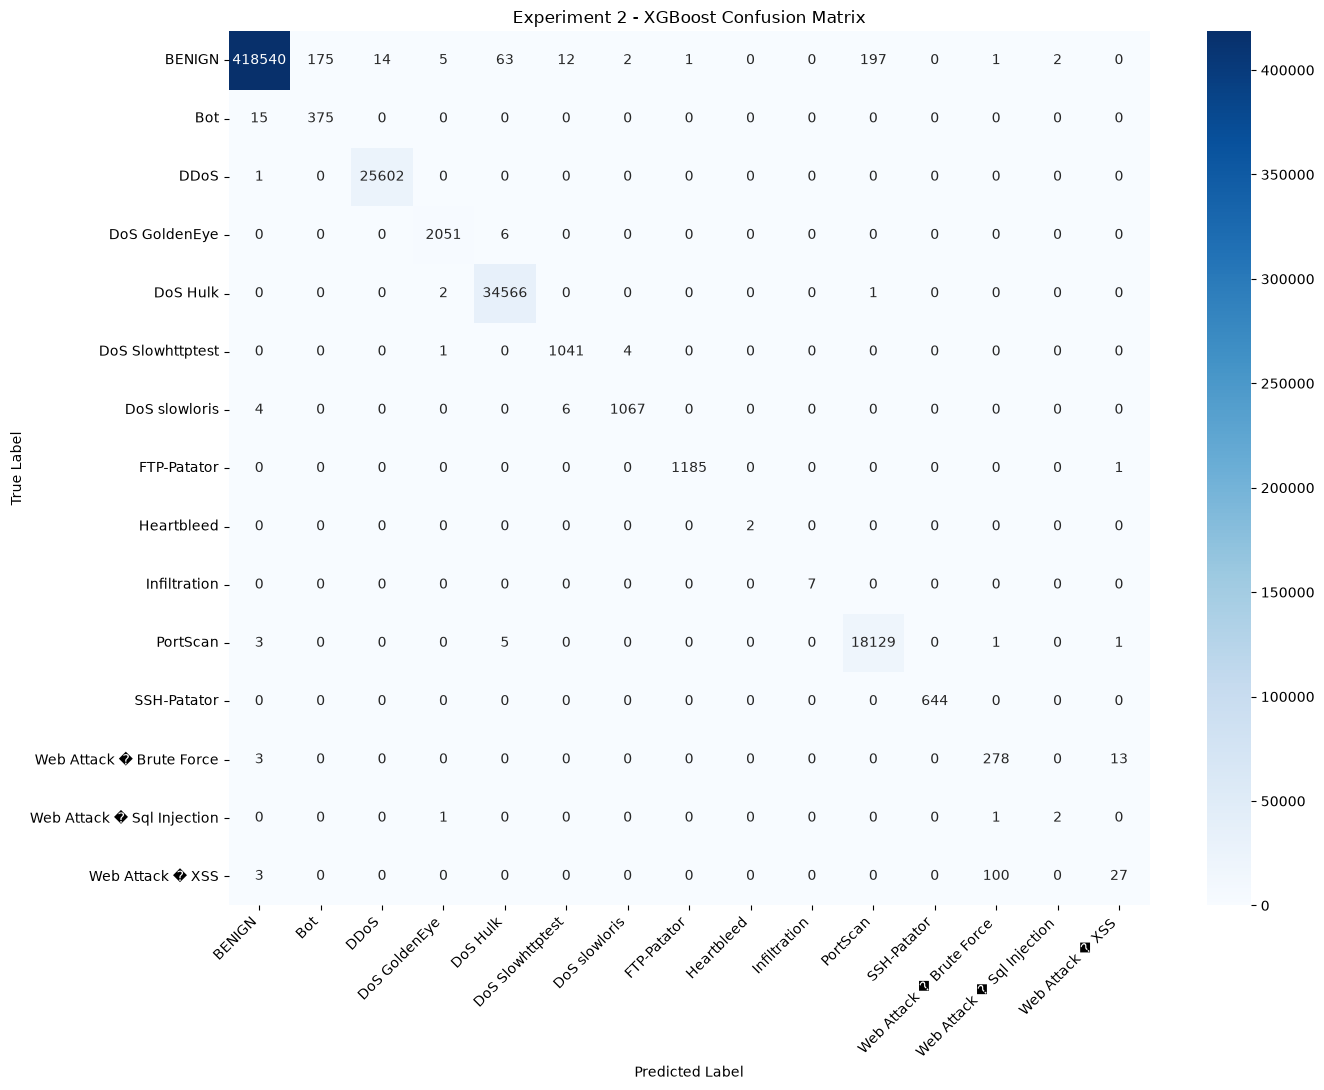

In [18]:
# =====================================================
# EXPERIMENT 2
# XGBOOST CONFUSION MATRIX
# =====================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

xgb_predictions = exp2_predictions["XGBoost"]

cm = confusion_matrix(
    y_test_encoded,
    xgb_predictions
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Experiment 2 - XGBoost Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [19]:
# =====================================================
# FINAL MODEL
# SAVE EXPERIMENT 2 XGBOOST
# =====================================================

import os
import joblib

os.makedirs("../data/models", exist_ok=True)

final_model = exp2_trained_models["XGBoost"]

final_model_path = "../data/models/xgboost_final_exp2.pkl"
final_scaler_path = "../data/models/xgboost_final_scaler.pkl"
final_labels_path = "../data/models/xgboost_label_encoder.pkl"

joblib.dump(
    final_model,
    final_model_path
)

joblib.dump(
    scaler_exp2,
    final_scaler_path
)

joblib.dump(
    label_encoder,
    final_labels_path
)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print(f"Model  : {final_model_path}")
print(f"Scaler : {final_scaler_path}")
print(f"Labels : {final_labels_path}")

FINAL MODEL SAVED
Model  : ../data/models/xgboost_final_exp2.pkl
Scaler : ../data/models/xgboost_final_scaler.pkl
Labels : ../data/models/xgboost_label_encoder.pkl


In [20]:
# =====================================================
# FINAL EXPERIMENT 2 RESULTS
# =====================================================

final_results_df = pd.DataFrame(
    exp2_results
)

final_results_df = final_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Macro Recall",
        "Macro F1",
        "Balanced Accuracy"
    ]
]

# Convert to percentages
display_results = final_results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy"
]

for column in metric_columns:

    display_results[column] = (
        display_results[column] * 100
    ).round(2)

print("=" * 60)
print("FINAL EXPERIMENT 2 RESULTS")
print("=" * 60)

display(display_results)

FINAL EXPERIMENT 2 RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Logistic Regression,95.99,96.80,95.99,96.13,66.69,61.53,66.69
1,Decision Tree,99.82,99.84,99.82,99.83,90.65,84.55,90.65
2,Random Forest,99.86,99.86,99.86,99.86,84.73,85.65,84.73
3,XGBoost,99.87,99.88,99.87,99.87,90.63,89.37,90.63


In [21]:
# =====================================================
# SAVE FINAL RESULTS
# =====================================================

os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/reports", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

final_results_path = (
    "../results/metrics/experiment_2_model_comparison.csv"
)

display_results.to_csv(
    final_results_path,
    index=False
)

print(
    f"Results saved to: {final_results_path}"
)

Results saved to: ../results/metrics/experiment_2_model_comparison.csv


In [22]:
# =====================================================
# SAVE FINAL XGBOOST CLASSIFICATION REPORT
# =====================================================

xgb_predictions = exp2_predictions["XGBoost"]

report_dict = classification_report(
    y_test_encoded,
    xgb_predictions,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

xgb_report_df = pd.DataFrame(
    report_dict
).transpose()

xgb_report_path = (
    "../results/reports/xgboost_final_classification_report.csv"
)

xgb_report_df.to_csv(
    xgb_report_path
)

print(
    f"Classification report saved to: "
    f"{xgb_report_path}"
)

display(xgb_report_df)

Classification report saved to: ../results/reports/xgboost_final_classification_report.csv


,precision,recall,f1-score,support
BENIGN,0.999931,0.998874,0.999402,419012.000000
Bot,0.681818,0.961538,0.797872,390.000000
DDoS,0.999453,0.999961,0.999707,25603.000000
DoS GoldenEye,0.995631,0.997083,0.996357,2057.000000
DoS Hulk,0.997864,0.999913,0.998887,34569.000000
DoS Slowhttptest,0.983003,0.995220,0.989074,1046.000000
DoS slowloris,0.994408,0.990715,0.992558,1077.000000
FTP-Patator,0.999157,0.999157,0.999157,1186.000000
Heartbleed,1.000000,1.000000,1.000000,2.000000
Infiltration,1.000000,1.000000,1.000000,7.000000


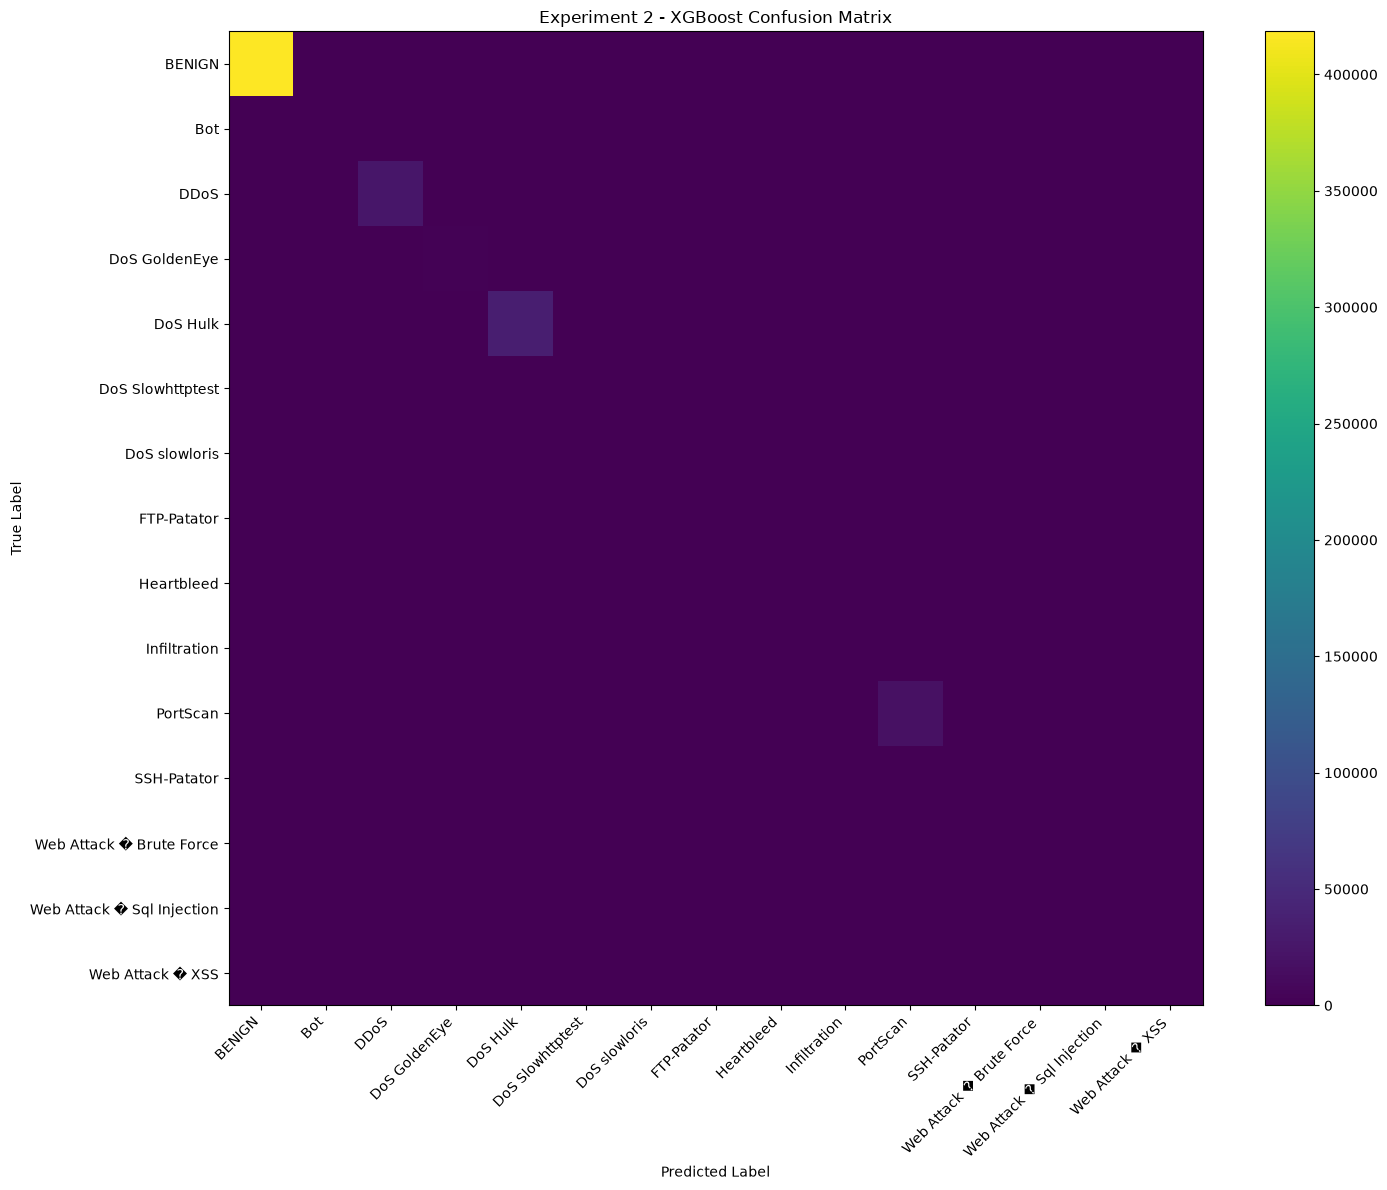

Confusion matrix saved to: ../results/figures/xgboost_confusion_matrix.png


In [23]:
# =====================================================
# SAVE FINAL XGBOOST CONFUSION MATRIX
# =====================================================

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    xgb_predictions
)

plt.figure(figsize=(15, 12))

plt.imshow(cm, interpolation="nearest")
plt.title(
    "Experiment 2 - XGBoost Confusion Matrix"
)

plt.colorbar()

classes = label_encoder.classes_

tick_marks = range(len(classes))

plt.xticks(
    tick_marks,
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

cm_path = (
    "../results/figures/xgboost_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Confusion matrix saved to: {cm_path}"
)

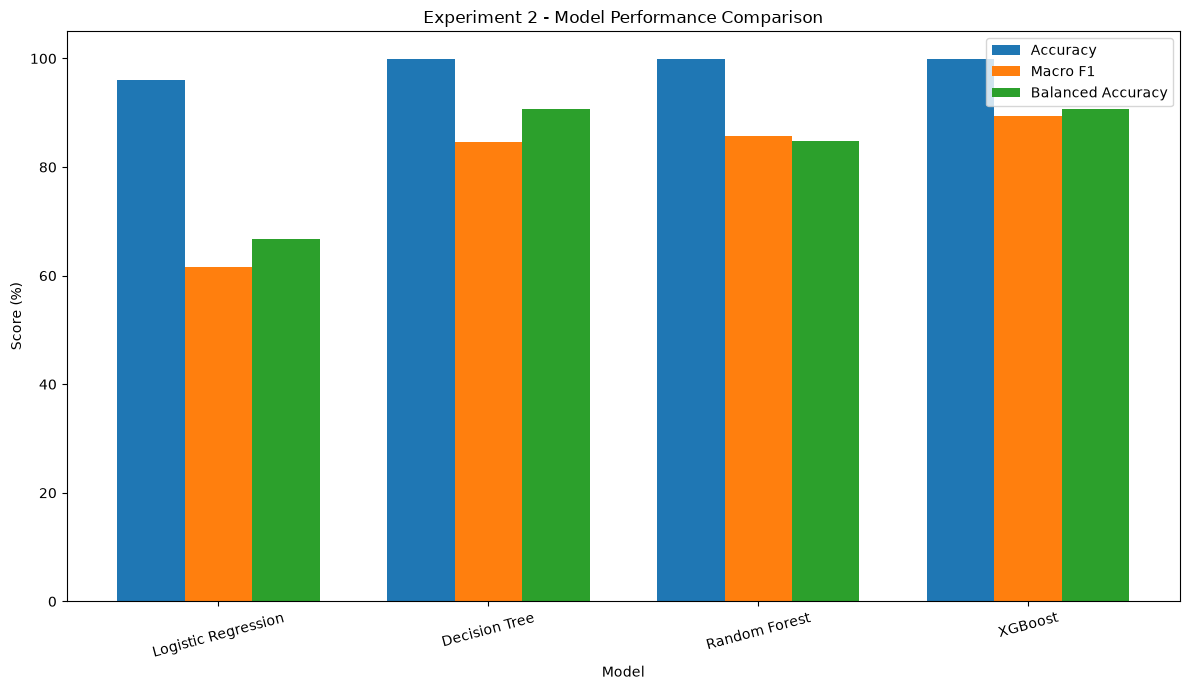

Comparison graph saved to: ../results/figures/experiment_2_model_comparison.png


In [24]:
# =====================================================
# FINAL MODEL COMPARISON
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

models_names = display_results["Model"]

x = np.arange(len(models_names))

accuracy_values = (
    display_results["Accuracy"]
)

macro_f1_values = (
    display_results["Macro F1"]
)

balanced_acc_values = (
    display_results["Balanced Accuracy"]
)

width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(
    x - width,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x,
    macro_f1_values,
    width,
    label="Macro F1"
)

plt.bar(
    x + width,
    balanced_acc_values,
    width,
    label="Balanced Accuracy"
)

plt.xticks(
    x,
    models_names,
    rotation=15
)

plt.ylabel("Score (%)")

plt.xlabel("Model")

plt.title(
    "Experiment 2 - Model Performance Comparison"
)

plt.legend()

plt.ylim(0, 105)

plt.tight_layout()

comparison_path = (
    "../results/figures/experiment_2_model_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Comparison graph saved to: "
    f"{comparison_path}"
)